In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("credit_risk_dataset.csv/credit_risk_dataset.csv")

# length and info
print("Length: ", df.shape[0])
print("Features: ", df.shape[1])

print("Feature names: ", df.columns.to_list())
df.head()

Length:  32581
Features:  12
Feature names:  ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
# checking for nan values
print("NAN cols in Percent: ")
print(round(df.isna().sum() / df.shape[0] * 100,2))

NAN cols in Percent: 
person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64


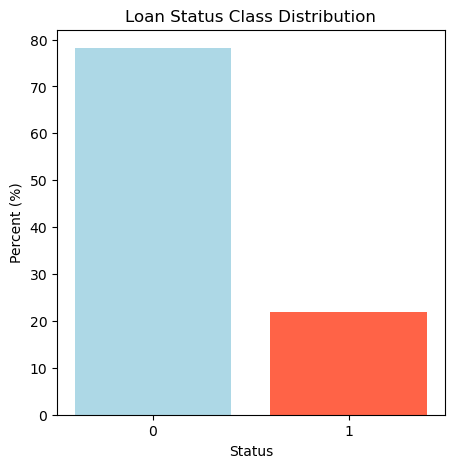

In [5]:
# checking for class imbalance with our target variable (loan_status)
target_dist = df.loan_status.value_counts() / df.shape[0] * 100

plt.figure(figsize=(5,5))
plt.bar(target_dist.index.astype(str), target_dist, color=["lightblue", "tomato"])
plt.title("Loan Status Class Distribution")
plt.xlabel("Status")
plt.ylabel("Percent (%)")
plt.show()

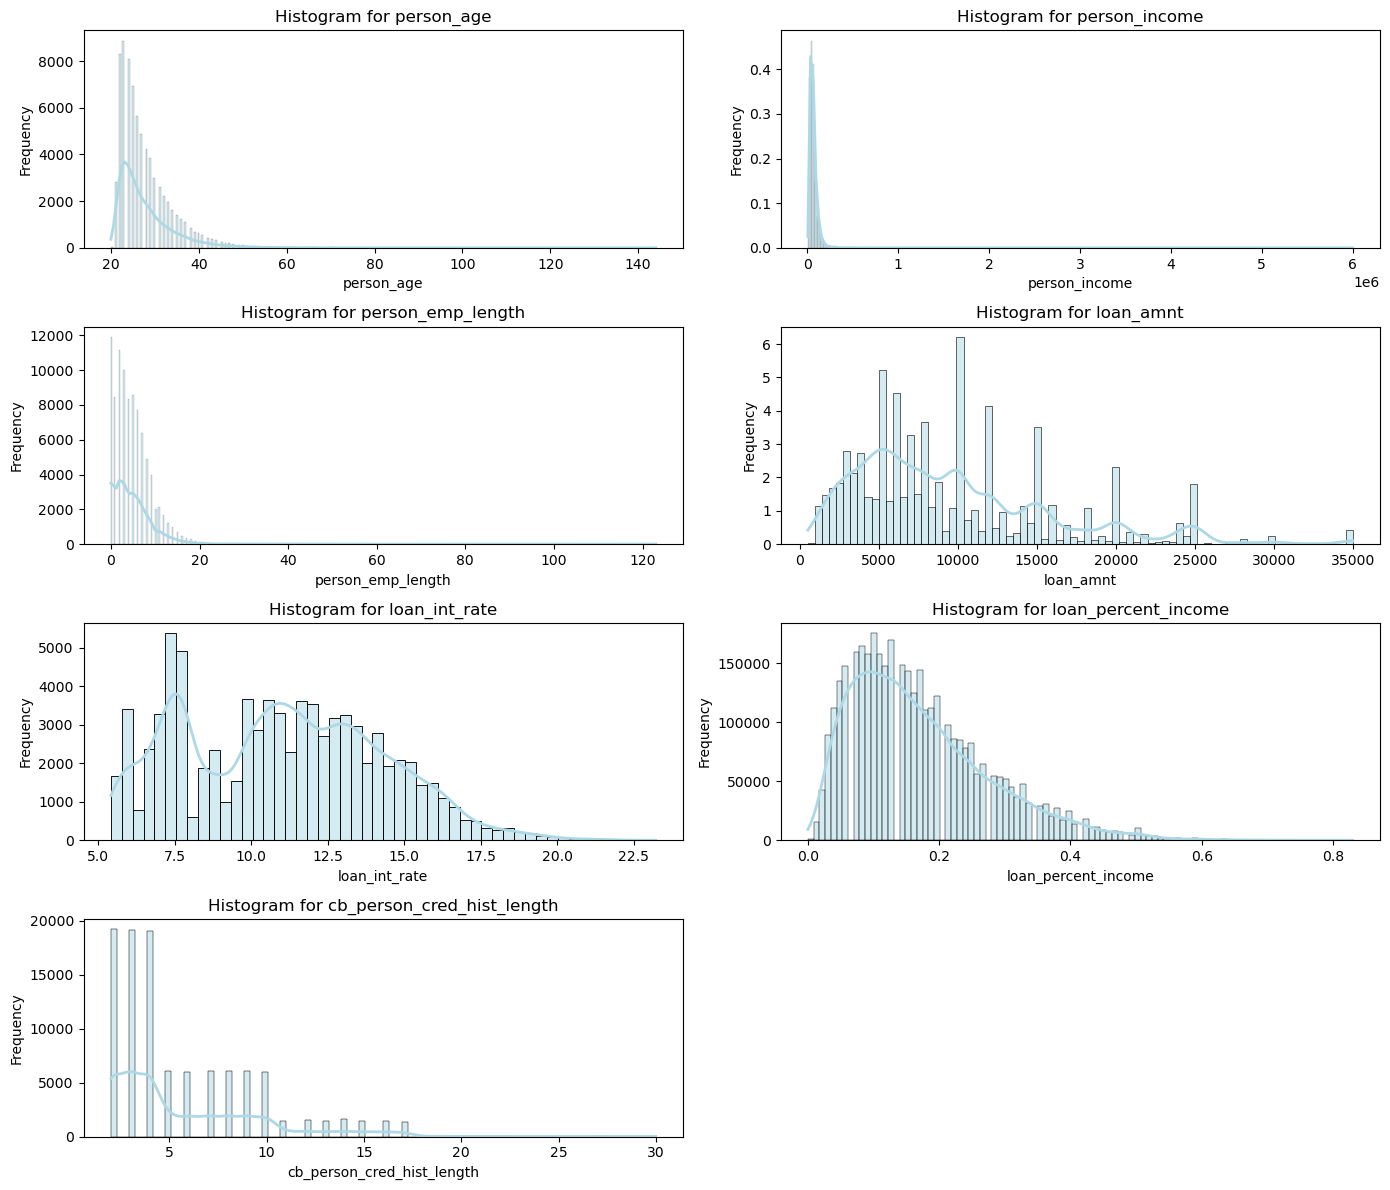

In [6]:
# exploring distribution of numeric 
# numeric cols
numeric_cols = df.select_dtypes(include="number").columns.drop("loan_status")
numeric_cols

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df,
        kde=True,
        x = col,
        color="lightblue",
        edgecolor="black",
        line_kws={"color": "red", "linewidth": 2},
        stat="frequency",
        ax= axes[i]
    )
    axes[i].set_xlabel(f"{col}")
    axes[i].set_title(f"Histogram for {col}")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

The above histogram shows that most of our features are right skewed and hence suggests potential transformation for models like Logistice Regression as large values could significantly dominate the regression line.

Datasets also show Nan values that needs to be addressed for modeling.
Around 2.75% of person_emp_length are nan while 9.56% for loan_int_rate

There is also class imabalance for loan_amount in our dataset which often results in accurate accuracy assumptions for our models.
- Proper metrics like f1, recall and precision should be used for evaluation.
- Oversampling like SMOTE or undersampling method could also be used for accuracy enhancement.


## Data Cleaning and Preprocessing

In [7]:
# we will be removing loan_percent_income as it is a derived variable from the ratio of loan and income
df1 = df.copy()
df1.drop("loan_percent_income", axis=1, inplace=True)
df1.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [8]:
# splitting independent and dependent variables
X = df1.drop("loan_status", axis=1)
y = df1["loan_status"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.1,
    random_state=23,
    stratify=y
)

print("X_train", X_train.shape)
print("y_train", y_train.shape)

X_train (29322, 10)
y_train (29322,)


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    FunctionTransformer,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1. Numeric columns that need log transformation
log_cols = [
    "person_income",
    "loan_amnt"
]

# 2. Numeric columns that should not be log-transformed
other_num_cols = [
    "person_age",
    "person_emp_length",
    "loan_int_rate",
    "cb_person_cred_hist_length"
]

# 3. Numeric pipeline with log transformation
log_num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

# 4. Numeric pipeline without log transformation
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 5. Ordinal categorical pipeline
grade_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=[["A", "B", "C", "D", "E", "F", "G"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
    ("scaler", StandardScaler())
])

# 6. Nominal categorical pipeline
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oh_encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

# 7. Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_num_transformer, log_cols),
        ("num", num_transformer, other_num_cols),
        ("grade", grade_transformer, ["loan_grade"]),
        ("cat", cat_transformer, [
            "loan_intent",
            "cb_person_default_on_file",
            "person_home_ownership"
        ])
    ],
    remainder="drop"
)

In [10]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,cb_person_default_on_file,cb_person_cred_hist_length
28469,33,160000,MORTGAGE,3.0,DEBTCONSOLIDATION,B,22000,10.75,N,9
1422,23,69000,RENT,0.0,MEDICAL,A,1000,7.29,N,3
31630,46,104000,MORTGAGE,1.0,EDUCATION,E,30000,18.39,N,15
32157,36,60000,RENT,2.0,HOMEIMPROVEMENT,B,15000,NaN,N,12
26614,27,35040,RENT,11.0,MEDICAL,B,2000,10.99,N,10


In [11]:
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    recall_score, 
    precision_score, 
    ConfusionMatrixDisplay
)

def evaluate(name, y_preds, y_test):
    result = {
        "model": name,
        "accuracy": round(accuracy_score(y_preds, y_test),3),
        "precision": round(precision_score(y_preds, y_test),3),
        "recall": round(recall_score(y_preds, y_test),3),
        "f1": round(f1_score(y_preds, y_test),3),
    }
    print(classification_report(y_preds, y_test))

    c_matrix=confusion_matrix(y_preds, y_test)
    disp=ConfusionMatrixDisplay(c_matrix, display_labels=[0,1])
    disp.plot()
    plt.show()
    return result

In [12]:
results = []
def add_results(result):
    if result not in results:
        results.append(result)

## Logistic Regression (Baseline) 

In [13]:
from sklearn.linear_model import LogisticRegression

# creating our first baseline model
lasso_clf = Pipeline([
    ("preprocessor" ,preprocessor),
    ("lasso", LogisticRegression(solver="liblinear", l1_ratio=1, class_weight="balanced"))
])
lasso_clf.fit(X_train, y_train)
print(f"Training Score: {lasso_clf.score(X_train, y_train)}")

Training Score: 0.777061591978719


              precision    recall  f1-score   support

           0       0.76      0.93      0.84      2089
           1       0.78      0.48      0.59      1170

    accuracy                           0.77      3259
   macro avg       0.77      0.70      0.71      3259
weighted avg       0.77      0.77      0.75      3259



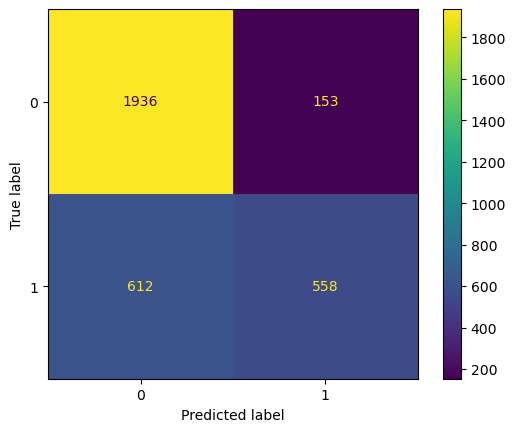

In [14]:
y_preds = lasso_clf.predict(X_test)
add_results(evaluate("lasso", y_preds, y_test))

### Decision Tree (baseline model)

In [15]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("decision_tree", DecisionTreeClassifier(max_depth=5, class_weight="balanced")),
])

decision_tree_model.fit(X_train, y_train)


decision_tree_model.score(X_train, y_train)

0.875861128163154

==============Decision Tree ================
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      2522
           1       0.73      0.71      0.72       737

    accuracy                           0.88      3259
   macro avg       0.82      0.82      0.82      3259
weighted avg       0.87      0.88      0.88      3259



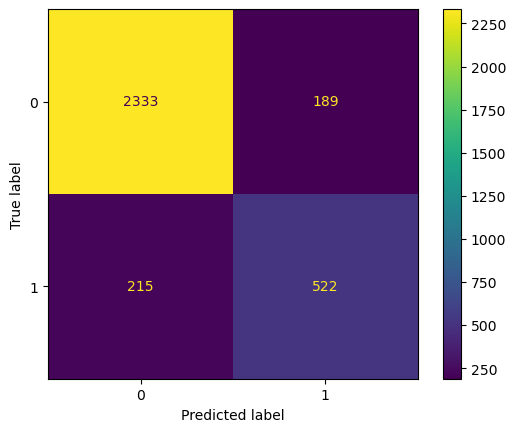

In [16]:
print("==============Decision Tree ================")
y_preds = decision_tree_model.predict(X_test)
add_results(evaluate("Decision Tree", y_preds, y_test))

In [17]:
results

[{'model': 'lasso',
  'accuracy': 0.765,
  'precision': 0.785,
  'recall': 0.477,
  'f1': 0.593},
 {'model': 'Decision Tree',
  'accuracy': 0.876,
  'precision': 0.734,
  'recall': 0.708,
  'f1': 0.721}]

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("gradient_boosting", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        min_samples_leaf=8,
        verbose=1,
        random_state=42))
])

gradient_boosting_model.fit(X_train, y_train)
gradient_boosting_model.score(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           0.9609           21.41s
         2           0.8985           21.25s
         3           0.8487           21.22s
         4           0.8083           21.15s
         5           0.7744           20.97s
         6           0.7422           20.83s
         7           0.7145           20.80s
         8           0.6913           20.72s
         9           0.6718           20.62s
        10           0.6537           20.52s
        20           0.5425           19.87s
        30           0.5031           19.14s
        40           0.4755           18.41s
        50           0.4534           17.67s
        60           0.4408           16.96s
        70           0.4287           16.24s
        80           0.4177           15.52s
        90           0.4096           14.83s
       100           0.4015           14.12s
       200           0.3397            7.02s
       300           0.2935            0.00s


0.9497305777232112

In [19]:
gradient_boosting_model.score(X_test, y_test)

0.928198833998159

              precision    recall  f1-score   support

           0       0.98      0.93      0.96      2704
           1       0.73      0.93      0.82       555

    accuracy                           0.93      3259
   macro avg       0.86      0.93      0.89      3259
weighted avg       0.94      0.93      0.93      3259



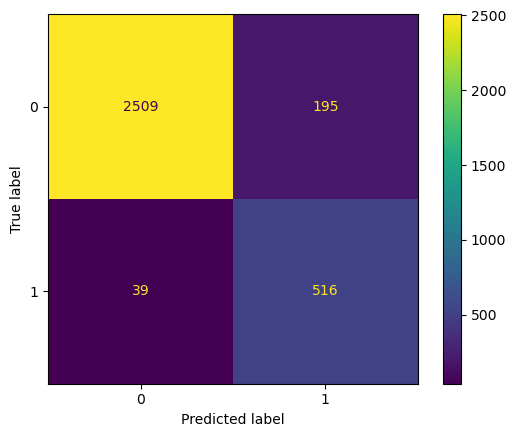

{'model': 'Gradient Boosting',
 'accuracy': 0.928,
 'precision': 0.726,
 'recall': 0.93,
 'f1': 0.815}

In [20]:
y_preds = gradient_boosting_model.predict(X_test)
evaluate("Gradient Boosting", y_preds, y_test)

In [41]:
import tensorflow as tf
from tensorflow import keras

# dataset for neural network
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# defining our neural network
# number of classes
NB_Classes = 1

# creating a sequential network
nn_model = keras.models.Sequential()

# adding first layer
nn_model.add(keras.layers.Dense(
    32,
    input_shape=(X_train_preprocessed.shape[1],),
    name="hidden-layer1",
    activation="relu"
))

# adding second layer
nn_model.add(keras.layers.Dense(
    16,
    name="hidden-layer2",
    activation="relu"
))

# outplut layer
nn_model.add(keras.layers.Dense(
    NB_Classes,
    name="output_layer",
    activation="sigmoid"
))

nn_model.compile(loss="binary_crossentropy", metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ])
nn_model.summary()

C:\Users\Yogsh\Desktop\ML-projects\env\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden-layer1 (Dense)                │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden-layer2 (Dense)                │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

{np.int64(0): np.float64(0.6395201744820066), np.int64(1): np.float64(2.291855557292481)}
Epoch 1/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7639 - loss: 0.4768 - precision: 0.4746 - recall: 0.7868 - val_accuracy: 0.8023 - val_loss: 0.4218 - val_precision: 0.5376 - val_recall: 0.7708
Epoch 2/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8157 - loss: 0.4164 - precision: 0.5527 - recall: 0.8060 - val_accuracy: 0.8241 - val_loss: 0.3938 - val_precision: 0.5749 - val_recall: 0.7908
Epoch 3/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8310 - loss: 0.3975 - precision: 0.5806 - recall: 0.8063 - val_accuracy: 0.8374 - val_loss: 0.3785 - val_precision: 0.6014 - val_recall: 0.7892
Epoch 4/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8414 - loss: 0.3851 - precision: 0.6016 - recall: 0.8049 - val_accuracy: 0.8456 - val_loss: 0.3657 - val_precision: 0.6209 - val_recall: 0.7785
Epoch 5/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8481

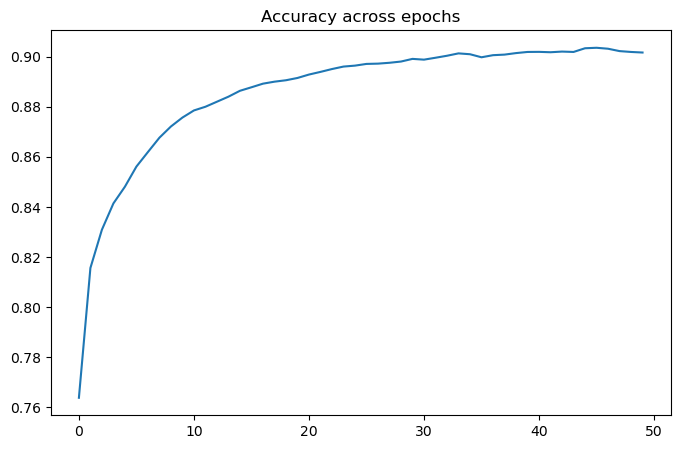

Neural Network Evaluation
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8926 - loss: 0.3029 - precision: 0.7651 - recall: 0.7328


[0.3028545677661896,
 0.8926050662994385,
 0.7650514245033264,
 0.7327707409858704]

In [42]:
from sklearn.utils.class_weight import compute_class_weight
# verbose
VERBOSE = 1

BATCH_SIZE = 32
EPOCHS = 50

VALIDATION_SPLIT = 0.1

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

history = nn_model.fit(
    X_train_preprocessed,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weights,
    verbose=VERBOSE
)

pd.DataFrame(history.history)["accuracy"].plot(figsize=(8,5))
plt.title("Accuracy across epochs")
plt.show()

print("Neural Network Evaluation")
nn_model.evaluate(X_test_preprocessed, y_test)